Phần 1

Câu 1


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Tải bộ dữ liệu 'titanic' từ seaborn
titanic = sns.load_dataset("titanic")

# Ý 1: In ra 5 dòng đầu tiên của tập dữ liệu
print("--- 1. Năm dòng đầu tiên của dữ liệu ---")
print(titanic.head())
print("\n" + "="*60 + "\n")

# Ý 2: In ra thông tin tổng quan của dữ liệu (dùng info())
print("--- 2. Thông tin tổng quan của dữ liệu ---")
titanic.info()

--- 1. Năm dòng đầu tiên của dữ liệu ---
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


--- 2. Thông tin tổng quan của dữ liệu ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null C

Câu 2


In [24]:
# Ý 1: Đếm số lượng giá trị khuyết ở mỗi cột
print("--- 1. Số lượng giá trị khuyết ở mỗi cột ---")
print(titanic.isnull().sum())
print("\n" + "="*60 + "\n")

# Ý 2: Xóa hoàn toàn cột 'deck' khỏi DataFrame (dùng errors='ignore' để không lỗi nếu lỡ chạy 2 lần)
titanic.drop(columns=['deck'], inplace=True, errors='ignore')
print("--- 2. Đã xóa cột 'deck'. Các cột hiện tại: ---")
print(titanic.columns.tolist())
print("\n" + "="*60 + "\n")

# Ý 3: Điền giá trị khuyết của 'age' bằng Trung bình (Mean)
age_mean = titanic['age'].mean()
titanic['age'] = titanic['age'].fillna(age_mean)
print(f"--- 3. Đã điền khuyết cột 'age' bằng giá trị trung bình: {age_mean:.2f} ---")
print("Số giá trị khuyết còn lại của 'age':", titanic['age'].isnull().sum())

--- 1. Số lượng giá trị khuyết ở mỗi cột ---
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


--- 2. Đã xóa cột 'deck'. Các cột hiện tại: ---
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']


--- 3. Đã điền khuyết cột 'age' bằng giá trị trung bình: 29.70 ---
Số giá trị khuyết còn lại của 'age': 0


Câu 3

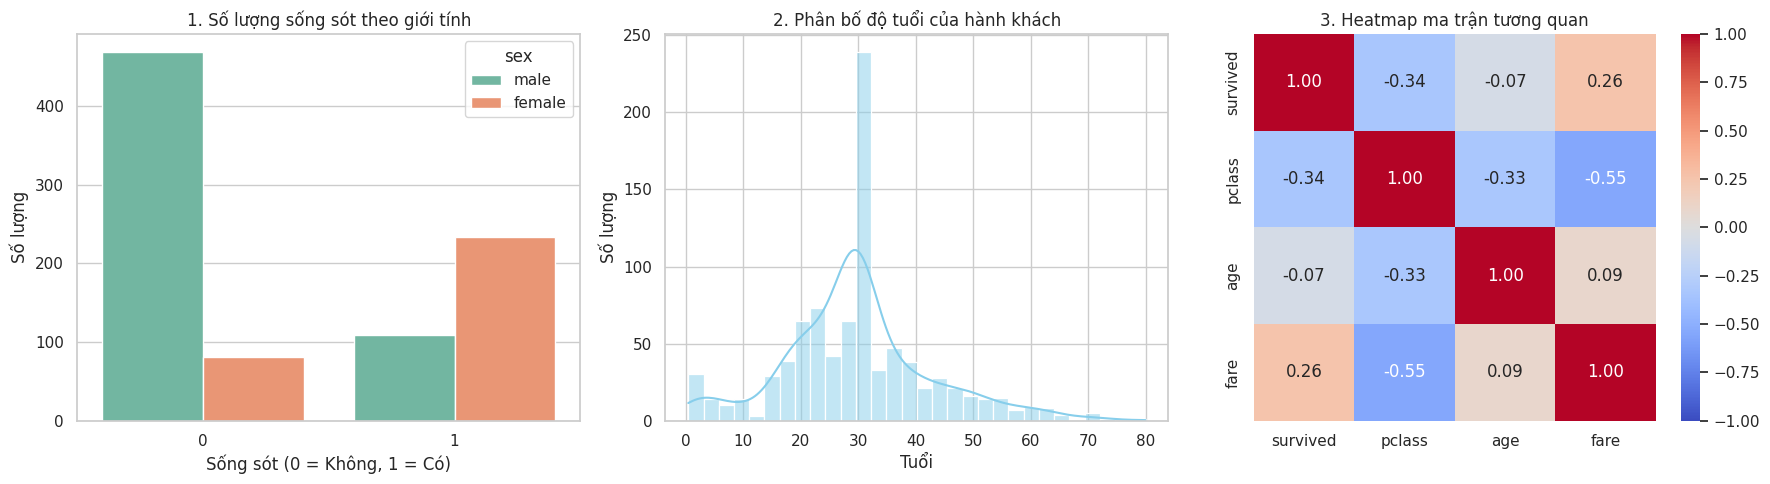

In [25]:
# Thiết lập phong cách biểu đồ
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 5))

# Ý 1: Biểu đồ cột (Count plot) sống sót phân chia theo giới tính
plt.subplot(1, 3, 1)
sns.countplot(data=titanic, x="survived", hue="sex", palette="Set2")
plt.title("1. Số lượng sống sót theo giới tính")
plt.xlabel("Sống sót (0 = Không, 1 = Có)")
plt.ylabel("Số lượng")

# Ý 2: Biểu đồ phân bố (Histogram + KDE) của 'age'
plt.subplot(1, 3, 2)
sns.histplot(data=titanic, x="age", kde=True, color="skyblue", bins=30)
plt.title("2. Phân bố độ tuổi của hành khách")
plt.xlabel("Tuổi")
plt.ylabel("Số lượng")

# Ý 3: Tính ma trận tương quan và vẽ Heatmap (chỉ lấy numeric cols)
plt.subplot(1, 3, 3)
numeric_cols = ["survived", "pclass", "age", "fare"]
# Chuyển ép kiểu an toàn trước khi tính tương quan
corr_matrix = titanic[numeric_cols].astype(float).corr()

# Vẽ heatmap với cmap='coolwarm'
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("3. Heatmap ma trận tương quan")

plt.tight_layout()
plt.show()

Cau 4

In [26]:
# Ý 1: Label Encoding (Map dictionary) cho cột 'sex'
# ('male' -> 0, 'female' -> 1)
titanic['sex'] = titanic['sex'].map({'male': 0, 'female': 1})
# Sửa lỗi NaN nếu lỡ chạy lại cell này bằng cách fillna bằng chính nó giữ nguyên logic
titanic['sex'] = titanic['sex'].fillna(titanic['sex'])

print("--- 1. Cột 'sex' sau khi mã hóa (5 dòng đầu) ---")
print(titanic[['sex']].head())
print("\n" + "="*60 + "\n")

# Ý 2: One-Hot Encoding cho 'embarked' và gộp vào DataFrame chính
# pd.get_dummies tạo ra các cột mới
embarked_dummies = pd.get_dummies(titanic['embarked'], prefix='embarked', dtype=int)

# Tránh trùng lặp nếu người dùng ấn Run nhiều lần (xóa cột cũ đi trước khi nối)
for col in embarked_dummies.columns:
    if col in titanic.columns:
        titanic.drop(columns=[col], inplace=True)

# Gộp vào DataFrame chính
titanic = pd.concat([titanic, embarked_dummies], axis=1)

print("--- 2. DataFrame sau khi gộp One-Hot Encoding (5 dòng đầu của vài cột) ---")
print(titanic[['embarked', 'embarked_C', 'embarked_Q', 'embarked_S']].head())

--- 1. Cột 'sex' sau khi mã hóa (5 dòng đầu) ---
   sex
0    0
1    1
2    1
3    1
4    0


--- 2. DataFrame sau khi gộp One-Hot Encoding (5 dòng đầu của vài cột) ---
  embarked  embarked_C  embarked_Q  embarked_S
0        S           0           0           1
1        C           1           0           0
2        S           0           0           1
3        S           0           0           1
4        S           0           0           1


Phần 2

Câu 5

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Ý 1: Tạo biến X (3 đặc trưng) và y (nhãn 'survived')
X = titanic[['pclass', 'sex', 'age']]
y = titanic['survived']

# Ý 2: Chia dữ liệu tỷ lệ 80% train - 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Kích thước X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Kích thước X_test: {X_test.shape}, y_test: {y_test.shape}")
print("\n" + "="*60 + "\n")

# Ý 3 (Khuyến khích): Chuẩn hóa dữ liệu bằng StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("--- X_train sau khi chuẩn hóa (3 dòng đầu) ---")
print(X_train_scaled[:3])

Kích thước X_train: (712, 3), y_train: (712,)
Kích thước X_test: (179, 3), y_test: (179,)


--- X_train sau khi chuẩn hóa (3 dòng đầu) ---
[[-1.61413602 -0.7243102   1.22920747]
 [-0.40055118 -0.7243102  -0.50350514]
 [ 0.81303367 -0.7243102   0.18957991]]


Câu 6

In [28]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Ý 1: Khởi tạo mô hình Sequential
model = Sequential()

# Ý 2: Thêm lớp ẩn (16 nơ-ron, activation 'relu', input_shape=(3,))
model.add(Dense(16, activation='relu', input_shape=(3,)))

# Ý 3: Thêm lớp đầu ra (1 nơ-ron, activation 'sigmoid' cho phân loại nhị phân)
model.add(Dense(1, activation='sigmoid'))

# Ý 4: Compile mô hình (optimizer 'adam', loss 'binary_crossentropy', metrics 'accuracy')
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("--- Thông tin kiến trúc mô hình (Summary) ---")
model.summary()
print("\n" + "="*60 + "\n")

# Ý 5: Huấn luyện mô hình (fit) với tập train trong 20 epochs
print("--- BẮT ĐẦU HUẤN LUYỆN (TRAINING) ---")
history = model.fit(X_train_scaled, y_train, epochs=20, verbose=1)

# Ý 5 (Tiếp): In ra kết quả đánh giá (evaluate) trên tập test
print("\n" + "="*60 + "\n")
print("--- KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ---")
loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"- Loss (Độ mất mát): {loss:.4f}")
print(f"- Accuracy (Độ chính xác): {accuracy:.4f} ({(accuracy * 100):.2f}%)")

--- Thông tin kiến trúc mô hình (Summary) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81 (324.00 B)

 Trainable params: 81 (324.00 B)

 Non-trainable params: 0 (0.00 B)



--- BẮT ĐẦU HUẤN LUYỆN (TRAINING) ---
Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5913 - loss: 0.7570
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6236 - loss: 0.7128
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6517 - loss: 0.6754
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6812 - loss: 0.6424
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7093 - loss: 0.6135
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7261 - loss: 0.5863
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7416 - loss: 0.5628
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7444 - loss: 0.5409
Epoch 9/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7640 - loss: 0.5237
Epoch 10/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7893 - loss: 0.5088 
Epoch 11/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7879 - loss: 0.4972
Epoch 12/20
23/23 ━━━━━━━━━━━━━━━